In [1]:
# ---- IMPORTS ----
import pandas as pd
import numpy as np

# ---- LOAD DATA ----
df = pd.read_csv('C:/Users/ASUS/OneDrive/Desktop/Data/hospitality-revenue-dashboard/data.csv')  # replace with your actual filename

# ---- FIRST LOOK ----
print(df.shape)        # how many rows and columns
print(df.head())       # first 5 rows
print(df.info())       # column types and nulls
print(df.isnull().sum()) # count missing values

(1000, 10)
   order_id        date        item_name  item_type  item_price  quantity  \
0         1  07-03-2022         Aalopuri   Fastfood          20        13   
1         2   8/23/2022          Vadapav   Fastfood          20        15   
2         3  11/20/2022          Vadapav   Fastfood          20         1   
3         4  02-03-2023  Sugarcane juice  Beverages          25         6   
4         5  10-02-2022  Sugarcane juice  Beverages          25         8   

   transaction_amount transaction_type received_by time_of_sale  
0                 260              NaN         Mr.        Night  
1                 300             Cash         Mr.    Afternoon  
2                  20             Cash         Mr.    Afternoon  
3                 150           Online         Mr.        Night  
4                 200           Online         Mr.      Evening  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             

In [2]:
# ---- IMPORTS ----
import pandas as pd
import numpy as np

# ---- LOAD DATA ----
df = pd.read_csv('C:/Users/ASUS/OneDrive/Desktop/Data/hospitality-revenue-dashboard/data.csv')  # adjust filename if different

# ---- FIRST LOOK ----
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (1000, 10)

First 5 rows:
   order_id        date        item_name  item_type  item_price  quantity  \
0         1  07-03-2022         Aalopuri   Fastfood          20        13   
1         2   8/23/2022          Vadapav   Fastfood          20        15   
2         3  11/20/2022          Vadapav   Fastfood          20         1   
3         4  02-03-2023  Sugarcane juice  Beverages          25         6   
4         5  10-02-2022  Sugarcane juice  Beverages          25         8   

   transaction_amount transaction_type received_by time_of_sale  
0                 260              NaN         Mr.        Night  
1                 300             Cash         Mr.    Afternoon  
2                  20             Cash         Mr.    Afternoon  
3                 150           Online         Mr.        Night  
4                 200           Online         Mr.      Evening  

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1

In [3]:
# ---- FIX DATES ----
df['date'] = pd.to_datetime(df['date'], dayfirst=False, infer_datetime_format=True)

# Extract useful time columns
df['month'] = df['date'].dt.month_name()
df['day_of_week'] = df['date'].dt.day_name()
df['month_num'] = df['date'].dt.month  # for sorting later

# ---- FIX MISSING TRANSACTION TYPE ----
df['transaction_type'] = df['transaction_type'].fillna('Unknown')

# ---- VERIFY ----
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDate range:")
print(df['date'].min(), "to", df['date'].max())
print("\nTime of sale values:")
print(df['time_of_sale'].value_counts())
print("\nTransaction types:")
print(df['transaction_type'].value_counts())

Missing values after cleaning:
order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
month                 0
day_of_week           0
month_num             0
dtype: int64

Date range:
2022-04-01 00:00:00 to 2023-03-30 00:00:00

Time of sale values:
Night        205
Afternoon    205
Evening      201
Midnight     199
Morning      190
Name: time_of_sale, dtype: int64

Transaction types:
Cash       476
Online     417
Unknown    107
Name: transaction_type, dtype: int64


In [4]:
print(df.shape)
print(df.columns.tolist())


(1000, 13)
['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity', 'transaction_amount', 'transaction_type', 'received_by', 'time_of_sale', 'month', 'day_of_week', 'month_num']


Revenue by Time of Sale:
time_of_sale
Night        62075
Afternoon    56345
Morning      53730
Evening      52355
Midnight     50725
Name: transaction_amount, dtype: int64

Revenue by Day of Week:
day_of_week
Monday       40930
Tuesday      36085
Wednesday    40380
Thursday     39905
Friday       36050
Saturday     37910
Sunday       43970
Name: transaction_amount, dtype: int64

Top 10 Items by Revenue:
item_name
Sandwich           65820
Frankie            57500
Cold coffee        54440
Sugarcane juice    31950
Panipuri           24520
Aalopuri           20880
Vadapav            20120
Name: transaction_amount, dtype: int64

Revenue by Category:
item_type
Beverages     86390
Fastfood     188840
Name: transaction_amount, dtype: int64

Monthly Revenue:
        month  transaction_amount
0     January               28670
1    February               25595
2       March               25390
3       April               17670
4         May               26570
5        June               17335
6 

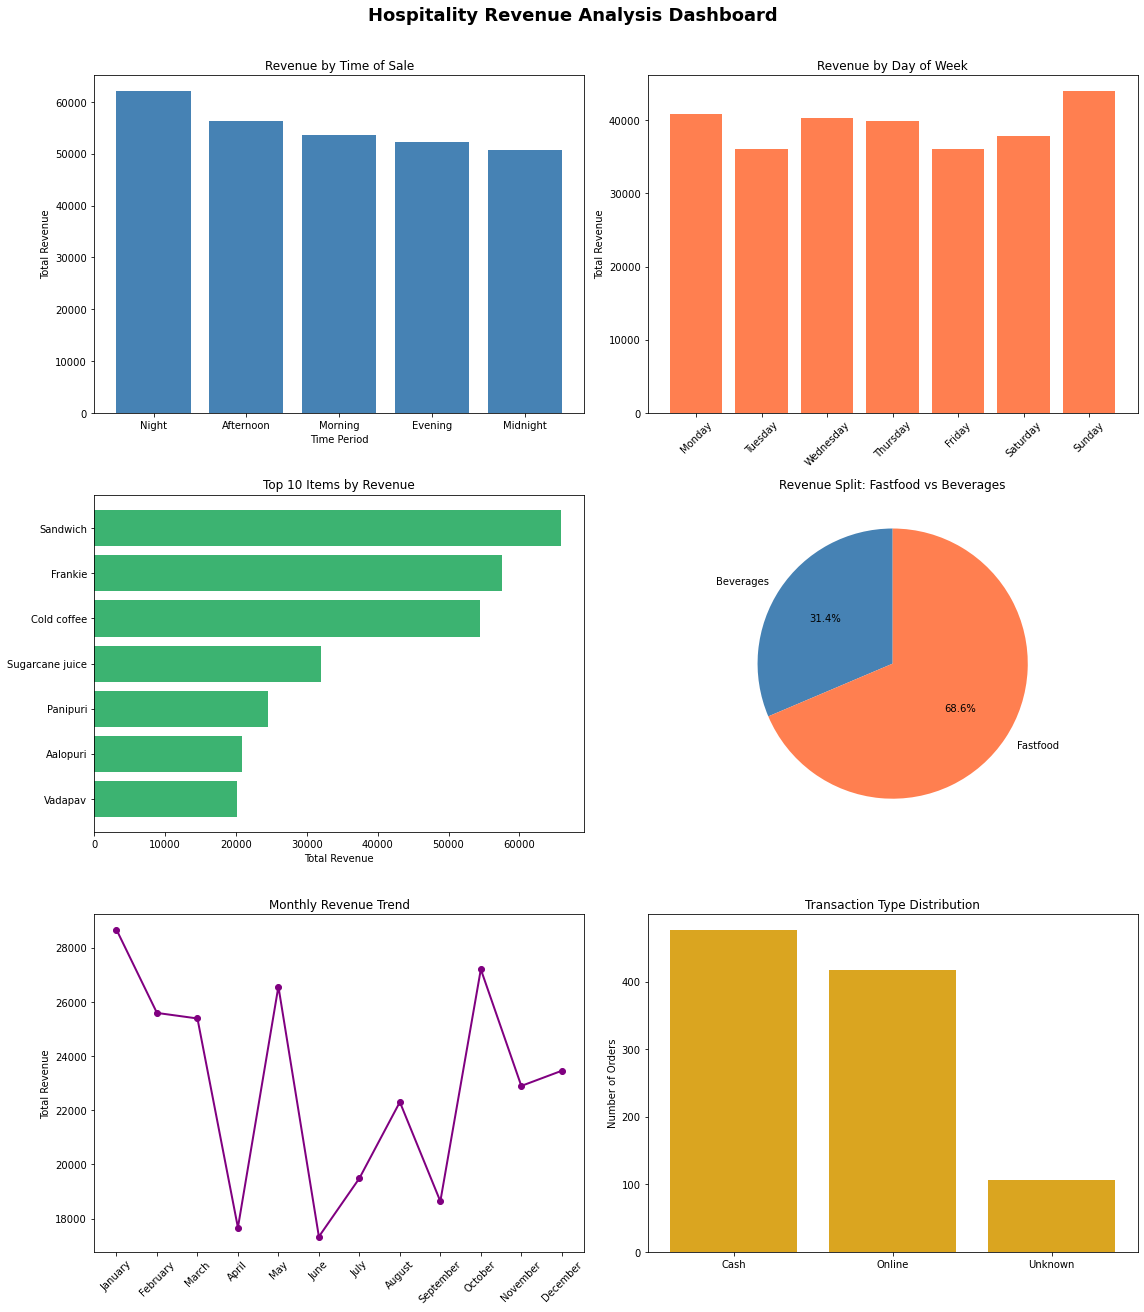


Chart saved as revenue_analysis.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---- 1. REVENUE BY TIME OF SALE ----
time_revenue = df.groupby('time_of_sale')['transaction_amount'].sum().sort_values(ascending=False)
print("Revenue by Time of Sale:")
print(time_revenue)

# ---- 2. REVENUE BY DAY OF WEEK ----
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = df.groupby('day_of_week')['transaction_amount'].sum().reindex(day_order)
print("\nRevenue by Day of Week:")
print(day_revenue)

# ---- 3. TOP SELLING ITEMS ----
top_items = df.groupby('item_name')['transaction_amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Items by Revenue:")
print(top_items)

# ---- 4. FASTFOOD vs BEVERAGES ----
category_revenue = df.groupby('item_type')['transaction_amount'].sum()
print("\nRevenue by Category:")
print(category_revenue)

# ---- 5. MONTHLY REVENUE TREND ----
monthly_revenue = df.groupby(['month_num','month'])['transaction_amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('month_num')
print("\nMonthly Revenue:")
print(monthly_revenue[['month','transaction_amount']])

# ---- PLOT ALL 5 ----
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Hospitality Revenue Analysis Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Plot 1 - Time of Sale
axes[0,0].bar(time_revenue.index, time_revenue.values, color='steelblue')
axes[0,0].set_title('Revenue by Time of Sale')
axes[0,0].set_ylabel('Total Revenue')
axes[0,0].set_xlabel('Time Period')

# Plot 2 - Day of Week
axes[0,1].bar(day_revenue.index, day_revenue.values, color='coral')
axes[0,1].set_title('Revenue by Day of Week')
axes[0,1].set_ylabel('Total Revenue')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Top Items
axes[1,0].barh(top_items.index, top_items.values, color='mediumseagreen')
axes[1,0].set_title('Top 10 Items by Revenue')
axes[1,0].set_xlabel('Total Revenue')
axes[1,0].invert_yaxis()

# Plot 4 - Category Split
axes[1,1].pie(category_revenue.values, labels=category_revenue.index,
              autopct='%1.1f%%', colors=['steelblue','coral'], startangle=90)
axes[1,1].set_title('Revenue Split: Fastfood vs Beverages')

# Plot 5 - Monthly Trend
axes[2,0].plot(monthly_revenue['month'], monthly_revenue['transaction_amount'],
               marker='o', color='purple', linewidth=2)
axes[2,0].set_title('Monthly Revenue Trend')
axes[2,0].set_ylabel('Total Revenue')
axes[2,0].tick_params(axis='x', rotation=45)

# Plot 6 - Transaction Type
trans_counts = df['transaction_type'].value_counts()
axes[2,1].bar(trans_counts.index, trans_counts.values, color='goldenrod')
axes[2,1].set_title('Transaction Type Distribution')
axes[2,1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as revenue_analysis.png")

In [6]:
# Clean monthly summary
monthly_summary = df.groupby(['month_num', 'month'])['transaction_amount'].sum().reset_index()
monthly_summary = monthly_summary.sort_values('month_num')
monthly_summary.columns = ['Month Number', 'Month', 'Total Revenue']
monthly_summary['% of Annual Revenue'] = (monthly_summary['Total Revenue'] / 
                                           monthly_summary['Total Revenue'].sum() * 100).round(1)
print(monthly_summary[['Month', 'Total Revenue', '% of Annual Revenue']].to_string(index=False))

    Month  Total Revenue  % of Annual Revenue
  January          28670                 10.4
 February          25595                  9.3
    March          25390                  9.2
    April          17670                  6.4
      May          26570                  9.7
     June          17335                  6.3
     July          19490                  7.1
   August          22305                  8.1
September          18640                  6.8
  October          27205                  9.9
 November          22900                  8.3
 December          23460                  8.5


In [7]:
# Export clean data for Power BI
df.to_csv('C:/Users/ASUS/OneDrive/Desktop/Data/hospitality-revenue-dashboard/clean_sales_data.csv', index=False)
print("Clean data exported successfully!")

Clean data exported successfully!


In [8]:
# Force month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Export again
df.to_csv('C:/Users/ASUS/OneDrive/Desktop/Data/hospitality-revenue-dashboard/clean_sales_data.csv', index=False)
print("Done! File exported with correct month order")

Done! File exported with correct month order
